In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# Data preprocessing 

## Handle Remove and messing values 

In [4]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [5]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [6]:
df["Age"] = 2026 - df["Year_Birth"]

In [7]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [8]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
referance_date = df["Dt_Customer"].max()

In [9]:
df["Customer_Tenure_days"] = (referance_date - df["Dt_Customer"]).dt.days
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [10]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_days'],
      dtype='str')

In [11]:
df["Total_spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [12]:
df["Total_of_child"] = df["Kidhome"] + df["Teenhome"]

In [13]:
df["Education"] = df["Education"].replace({
    "Basic":"Undergraduate",  "2n Cycle":"Undergraduate", 
     "Graduate":"Graduate", 
     "Master":"Postgraduate",  "PhD":"Postgraduate"
})

In [14]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [15]:
df["Living_with"] = df["Marital_Status"].replace({
     "Married":"Partner","Together":"Partner", 
     "Single":"Alone", "Divorced":"Alone", "Widow":"Alone", "Alone":"Alone",
     "Absurd":"Alone","YOLO":"Alone"
})

# Drop coloumns 

In [16]:
col = ['ID', 'Year_Birth', 'Marital_Status','Kidhome',
       'Teenhome','Dt_Customer']

spending_col =['MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']
cols_to_drop = col + spending_col

df_cleaned = df.drop(columns = cols_to_drop)

In [17]:
df_cleaned.shape

(2240, 15)

In [18]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_days', 'Total_spending',
       'Total_of_child', 'Living_with'],
      dtype='str')

# Outlier

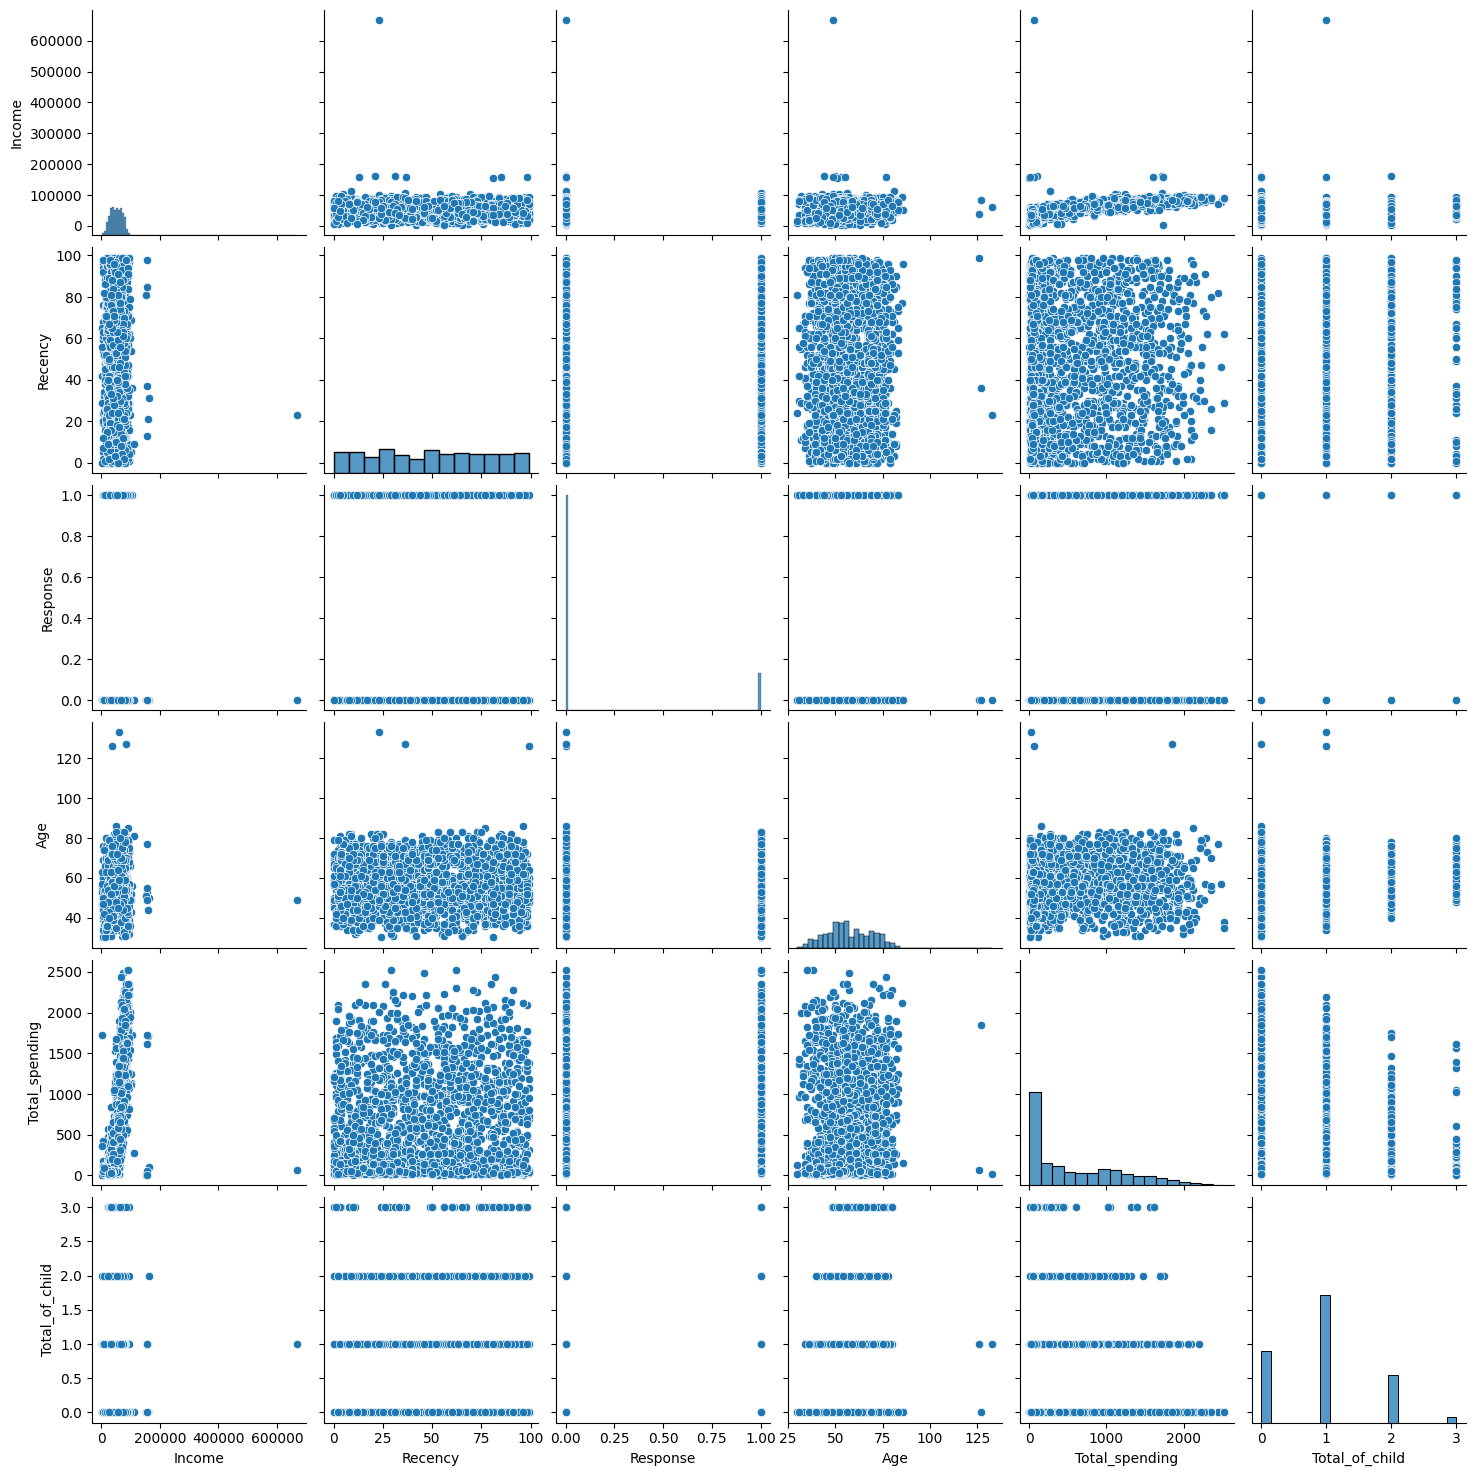

In [19]:
cols = ["Income", "Recency", "Response", "Age","Total_spending", "Total_of_child"]

sns.pairplot(df_cleaned[cols])

In [20]:
df_cleaned = df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned = df_cleaned[(df_cleaned["Income"]<600_000)]

# Heatmap

<Axes: >

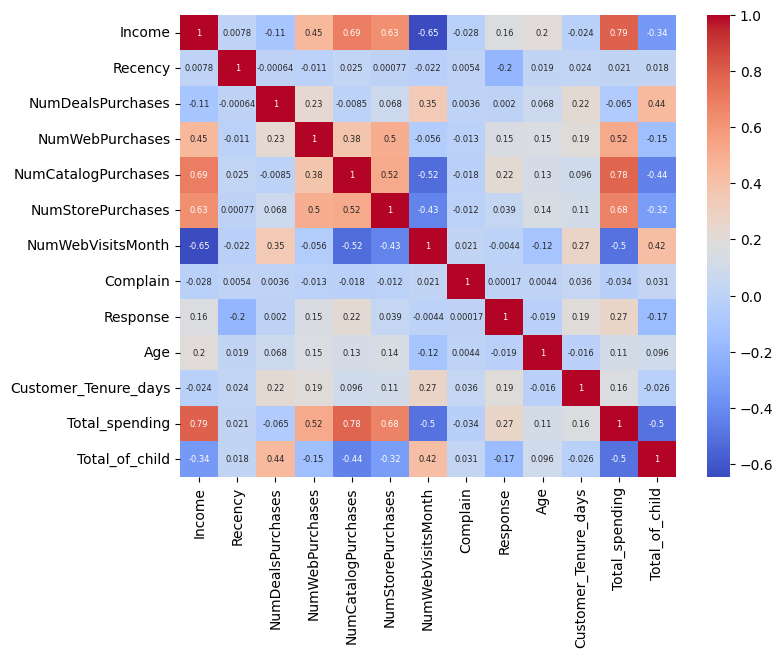

In [21]:
corr = df_cleaned.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 6},
    cmap="coolwarm"
)

In [22]:
from sklearn.preprocessing import OneHotEncoder

In [23]:
ohe = OneHotEncoder()
cat_col = ["Education","Living_with"]
enc_cols = ohe.fit_transform(df_cleaned[cat_col])
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_col), index=df_cleaned.index)

In [24]:
enc_df.head()

,Education_Graduation,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [25]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_col), enc_df], axis=1)

In [26]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_spending,Total_of_child,Education_Graduation,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# Sacling 

In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
scaler = StandardScaler()
X = df_encoded
X_pca= scaler.fit_transform(X)

In [29]:
from sklearn.decomposition import PCA

Text(0.5, 0.92, '3D projection')

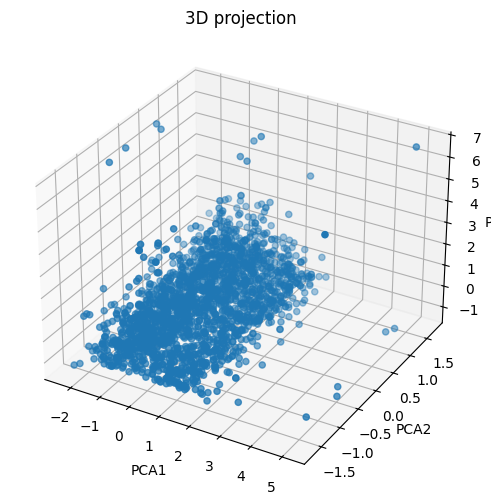

In [30]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D projection")

# Analyze K value 
## 1. Elbow Methods

In [31]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [32]:
knee = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

## 2. Silhouette score 

Text(0, 0.5, 'Silhouette score')

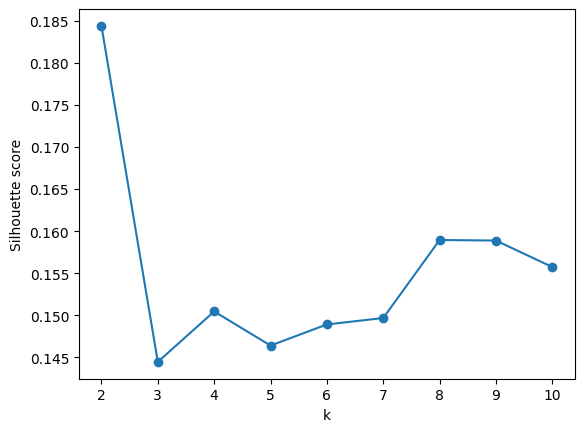

In [33]:
from sklearn.metrics import silhouette_score

scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

plt.plot(range(2,11), scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")

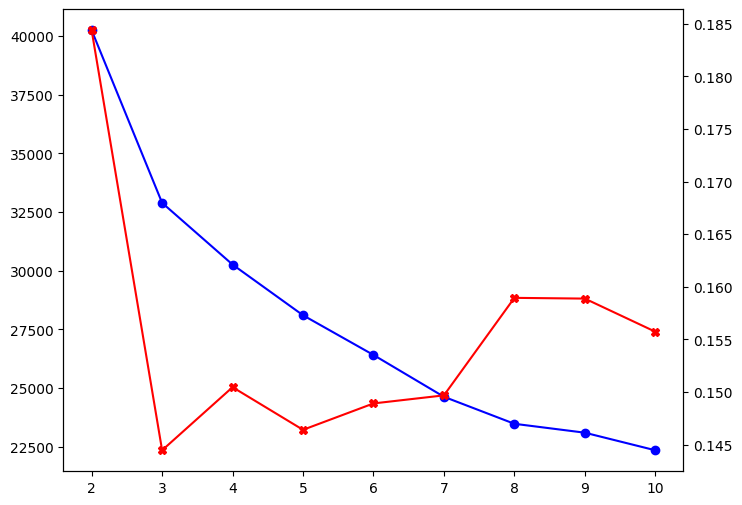

In [34]:
# combined plot 

k_range = range(2,11)
fig,ax1 = plt.subplots(figsize=(8,6))
ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="X", color="red")

In [35]:
# K means 
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

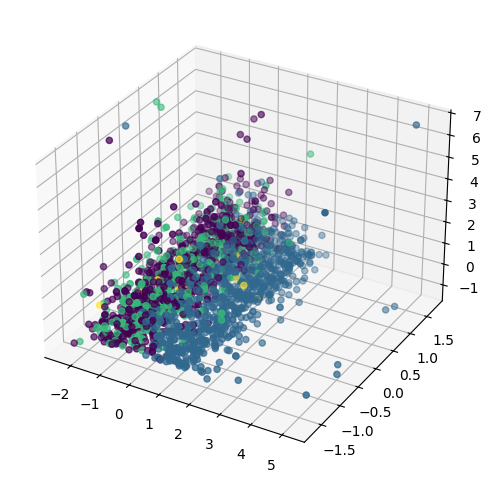

In [36]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=labels_kmeans)


In [37]:
#Agglomerative Clustring 

from sklearn.cluster import AgglomerativeClustering

In [38]:
agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
lables_agg = agg_clf.fit_predict(X_pca)

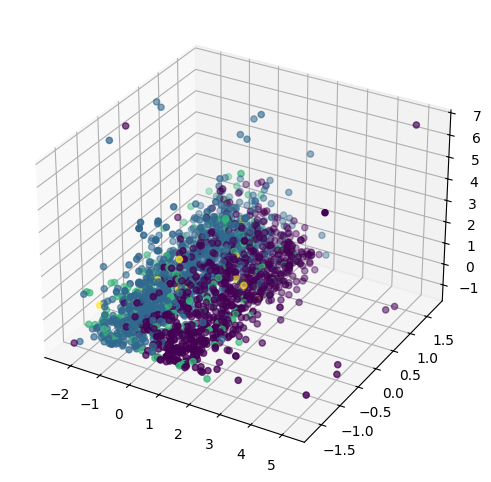

In [39]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=lables_agg)


# Characterizeation of Cluster

In [45]:
X["lables"] =lables_agg

In [46]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_spending,Total_of_child,Living_with,lables
0,Graduation,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone,0
1,Graduation,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone,1
2,Graduation,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner,0
3,Graduation,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner,1
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner,1


<Axes: xlabel='lables', ylabel='count'>

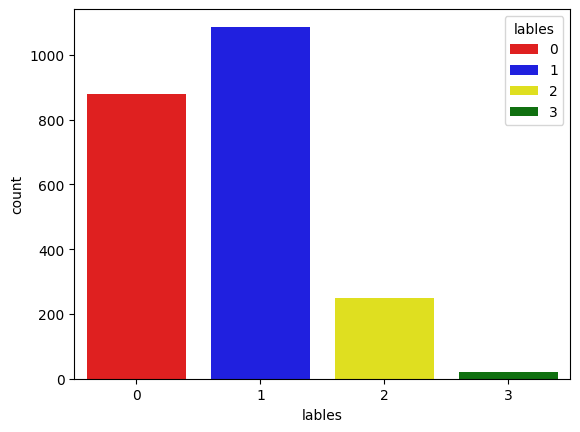

In [47]:
pal = ["red","blue", "yellow", "green"]

sns.countplot(x=X["lables"], palette=pal, hue=X["lables"])

<Axes: xlabel='Total_spending', ylabel='Income'>

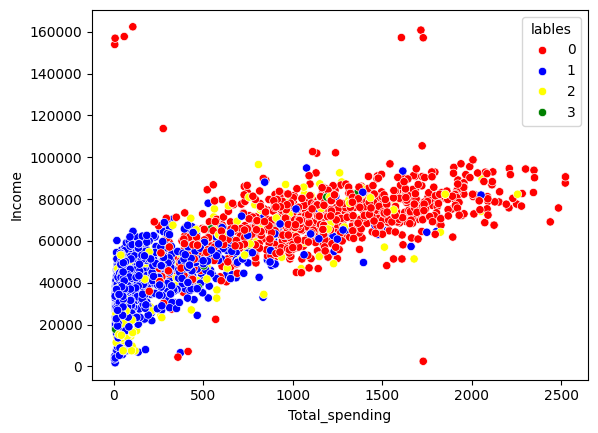

In [48]:
sns.scatterplot(x=X["Total_spending"], y=X["Income"], palette=pal, hue=X["lables"])

In [51]:
cluster_summary = X.groupby("lables").mean()
print(cluster_summary)

              Income    Recency  NumDealsPurchases  NumWebPurchases  \
lables                                                                
0       70236.518771  48.767918           2.006826         5.640501   
1       39639.048298  49.533579           2.641214         3.009200   
2       41708.206000  48.396000           2.072000         3.348000   
3       45672.400000  50.750000           2.400000         3.700000   

        NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
lables                                                                        
0                  4.923777           8.354949           3.782708       0.0   
1                  1.018399           3.936523           6.452622       0.0   
2                  1.912000           4.912000           5.748000       0.0   
3                  2.100000           5.400000           5.850000       1.0   

        Response        Age  Customer_Tenure_days  Total_spending  \
lables                       